## 002 - AppleCider Photometry
<a id='index'></a> <br>

- [part 1: import stuff, other basic things](#import)
    - if you haven't already processed the dataset into alerts, go back to [001: data pre-processing walkthrough](https://github.com/ajunell/AppleCider/blob/main/notebooks/001-data-processing.ipynb). you can skip to the `TransientDataset` part if you use `data_train.csv`, `data_test.csv`.
    - [config file](#config)
- [part 2: Dataset](#dataset)
- [part 3: DataLoader](#dataloader)

In [3]:
import pandas as pd
import numpy as np
import os
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import random
import torch
import joblib
import sys
sys.path.insert(0, '/AppleCider')

from AppleCider.preprocess.data_preprocessor import AlertProcessor, PhotometryProcessor, DataPreprocessor, SpectraProcessor
from AppleCider.preprocess.data_preprocessor import DataSorter
from AppleCider.preprocess.transient_dataset import TransientDataset
import AppleCider.preprocess.plot_data as plot_data


from AppleCider.preprocess.plot_data import plot_dataset

from AppleCider.core.model import Informer
from AppleCider.core.trainer import Trainer
from AppleCider.core.dataset import DataGenerator
import AppleCider.core.dataset as dataset

import AppleCider.core.drink as drink

from torch import nn

from datetime import datetime
import optuna 
from optuna.exceptions import DuplicatedStudyError
from torch.utils.data import DataLoader
import wandb
from torch.utils.data import Dataset
import pickle 

In [ ]:
wandb.login()

<a id='import'></a><br>

In [4]:
data_dir = 'SEDM_folder'
SEDM_dataset = pd.read_csv('/csv-pkl/SEDM_BrightTransientSurvey.csv')
CLASSES = ['SN Ia', 'SN II', 'SN IIP', 'Cataclysmic', 'AGN', 'SN IIn', 'SN Ic', 'SN Ib', 'SN IIb', 'Tidal Disruption Event']

TEST_DATA_PATH = 'data_test_BTS'
TRAIN_DATA_PATH ='data_train_BTS'

data_test = pd.read_csv('/csv-pkl/data_test_BTS.csv')
data_train = pd.read_csv('/csv-pkl/data_train_BTS.csv')

In [5]:
## create test, train, validation files from alert file names (i.e. ZTF18aaakpbx_alert_6.npy)
test_files, _ = DataSorter.split_train_validation_files(data_test, 'type', 100)
train_files, val_files = DataSorter.split_train_validation_files(data_train, 'type')

In [6]:
file_path= '/csv-pkl'
filename = os.path.join(file_path, 'test_files_BTS.pkl')
filename_train = os.path.join(file_path, 'train_files_BTS.pkl')
filename_val = os.path.join(file_path, 'val_files_BTS.pkl')

## write to file using pickle
#with open(filename, 'wb') as file:
#    pickle.dump(test_files, file)
#
#with open(filename_train, 'wb') as file:
#    pickle.dump(train_files, file)
#
#with open(filename_val, 'wb') as file:
#    pickle.dump(val_files, file)

# load files
with open(filename, 'rb') as file:
    test_files = pickle.load(file)
with open(filename_train, 'rb') as file:
    train_files = pickle.load(file)
with open(filename_val, 'rb') as file:
    val_files = pickle.load(file)

<big>part 2: Dataset</big><br>


<a id='dataset'></a><br>
<i><small>[back to index](#index)</small></i>
<a id='config'></a>

In [36]:
CLASSES = ['SN Ia', 'SN II', 'SN IIP', 'Cataclysmic', 'AGN', 'SN IIn', 'SN Ic', 'SN Ib', 'SN IIb', 'Tidal Disruption Event']

config = {
        'project': 'AppleCider',
        'mode': 'photo',    # 'clip' 'photo' 'spectra' 'meta' 'image' 'all'
        'config_from': None,
        'random_seed': 42,  # 42, 66, 0, 12, 123
        'use_wandb': True,
        'save_weights': False,
        'weights_path': f'/AppleCider/weights/{datetime.now().strftime("%Y-%m-%d-%H-%M")}',
        'use_pretrain': None,
        'freeze': False,

        ## Data General
        'preprocessed_path':'/data_train_BTS',
        'df_path': '/csv-pkl/data_train_BTS.csv',
        # save train, val file names ...
        'train_files_path': '/csv-pkl/train_files_BTS.pkl',
        'val_files_path': '/csv-pkl/val_files_BTS.pkl',
        'generate_train_val_files': False,
        'class_weights_path': '../csv-pkl/class_weights.pkl',
        'class_weights': True,

        'step': 'type',
        'classes': CLASSES,
        'group_labels': True,
        'max_samples': 800,
        'num_classes': len(CLASSES),

        ## Photometry Model
        'seq_len': 230,
        'p_enc_in': 4,
        'p_d_model': 128,
        'p_dropout': 0.2,
        'p_factor': 1,
        'p_output_attention': False,
        'p_n_heads': 12,
        'p_d_ff': 512,
        'p_activation': 'gelu',
        'p_e_layers': 8,


        ## Training
        'batch_size': 512,
        'lr': 0.001,
        'beta1': 0.9,
        'beta2': 0.999,
        'weight_decay': 0.01,
        'epochs':25,
        #'epochs': 100, 
        'early_stopping_patience': 10,
        #'early_stopping_patience': 60,
        'scheduler': 'ReduceLROnPlateau',  # 'ExponentialLR', 'ReduceLROnPlateau'
        'gamma': 0.9,  # for ExponentialLR scheduler
        'factor': 0.3,  # for ReduceLROnPlateau scheduler
        'patience': 3,  # for ReduceLROnPlateau scheduler
        'warmup': False,
        'warmup_epochs': 100,
        'clip_grad': False,
        'clip_value': 5
    }

In [37]:
train_dataset = DataGenerator(config=config, split='train')
val_dataset = DataGenerator(config=config, split='val')

In [38]:
photometry, _, _, _,target = train_dataset[50]
photometry.shape, \
photometry.dtype,

(torch.Size([230, 4]), torch.float32)

In [39]:
## we can get the obj id back from train_files (when not shuffled)
obj_id = train_files[50][:12]
print("obj id: ", obj_id)
photometry[:19]

obj id:  ZTF18aczqzrj


tensor([[ 0.0000, -0.7070,  0.6112,  0.0000],
        [ 0.0294, -0.7070,  0.3561,  0.0000],
        [ 0.0501, -0.7070,  0.5037,  0.0000],
        [ 0.0510, -0.7070,  0.4282,  0.0000],
        [ 0.9198,  1.4318, -1.3400,  0.0000],
        [ 0.9459,  1.4383, -1.3400,  0.0000],
        [ 0.9797, -0.7070,  0.5227,  0.0000],
        [ 1.0063, -0.7070,  0.4638,  0.0000],
        [ 1.9023,  1.4259, -1.3400,  0.0000],
        [ 1.9206,  1.3561, -1.3400,  0.0000],
        [ 1.9420,  1.4179, -1.3400,  0.0000],
        [ 2.0033, -0.7070,  0.5528,  0.0000],
        [ 2.0207, -0.7070,  0.6692,  0.0000],
        [ 2.0442, -0.7070,  0.8050,  0.0000],
        [ 5.9651, -0.7070,  1.7874,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000]])

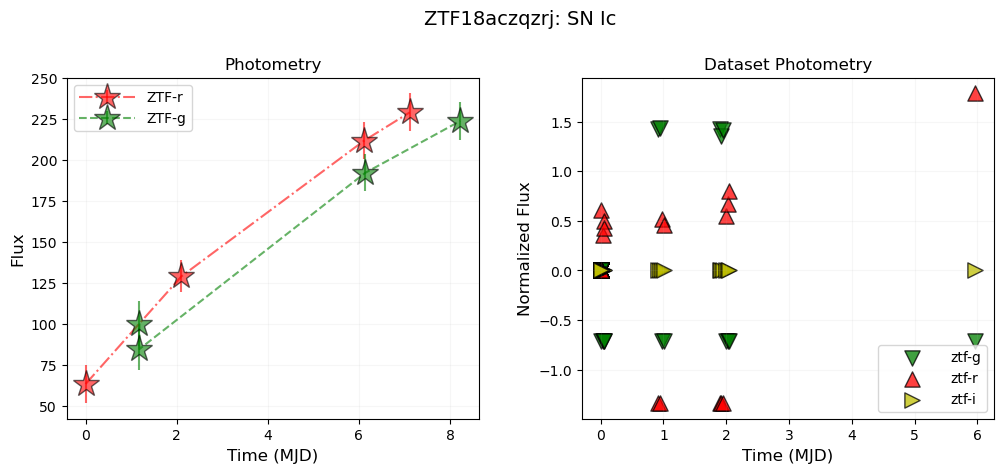

In [21]:
plot_dataset.compare_dataset_photometry(photometry, obj_id, SEDM_dataset, data_dir)

<a id='dataloader'></a>
<big>part 3: DataLoader</big>
    
    

<i><small>[back to index](#index)</small></i>

In [40]:
train_dataloader = DataLoader(train_dataset, batch_size=128, collate_fn = drink.collate_func,
                              shuffle=True, drop_last=True)
val_dataloader = DataLoader(val_dataset, batch_size=128 ,collate_fn = drink.collate_func,
                              shuffle=True)


In [41]:
batch = next(iter(train_dataloader))
photometry, photometry_mask, _, _, _, target = batch

In [42]:
photometry, photometry_mask, _, _, _, target  = batch
photometry.shape, photometry_mask.shape, target.shape,\
photometry.dtype, photometry_mask.dtype, target.dtype

(torch.Size([128, 230, 4]),
 torch.Size([128, 230]),
 torch.Size([128]),
 torch.float32,
 torch.float32,
 torch.int64)

In [43]:
#config = run.config

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using', device)

model = Informer(config)
model = model.to(device)

Using cpu


In [ ]:
model

In [45]:
with torch.no_grad():
    photometry, photometry_mask = photometry.to(device), photometry_mask.to(device)
    output = model(photometry, photometry_mask)

In [46]:
from torch.optim import Adam
from torch.optim.lr_scheduler import ExponentialLR, ReduceLROnPlateau, LinearLR

optimizer = Adam(model.parameters(), lr=config['lr'], betas=(config['beta1'], config['beta2']),
                 weight_decay=config['weight_decay'])
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=config['factor'], patience=config['patience'])
criterion = torch.nn.CrossEntropyLoss()

In [ ]:
wandb.init(
    project=config['project'],
    config=config, group='BTS_reboot')

In [ ]:
warmup_scheduler = LinearLR(optimizer, start_factor=1e-5, end_factor=1, total_iters=config['warmup_epochs'])

trainer = Trainer(model=model, optimizer=optimizer, scheduler=scheduler, warmup_scheduler=warmup_scheduler,
                  criterion=criterion, device=device, config=config)

# works until here
trainer.train(train_dataloader, val_dataloader, epochs=config['epochs'])

In [ ]:
conf_matrix = trainer.evaluate(test_dataloader, id2target={0: 'SN Ia', 1: 'SN II',2: 'SN IIP', 3: 'Cataclysmic', 4: 'AGN',  5: 'SN IIn', 6: 'SN Ic',7: 'SN Ib', 8: 'SN IIb', 9: 'Tidal Disruption Event'})